In [1]:
!pip install -q transformers torch nltk scikit-learn lime matplotlib

import os
import re
import nltk
import urllib.request
import tarfile
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import pipeline
from lime.lime_text import LimeTextExplainer

nltk.download('stopwords')
nltk.download('punkt')
print('All libraries imported successfully!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [2]:
url = 'https://www.cs.jhu.edu/~mdredze/datasets/sentiment/domain_sentiment_data.tar.gz'
tar_path = 'domain_sentiment_data.tar.gz'
extract_path = 'sentiment_data'

if not os.path.exists(extract_path):
    print('Downloading dataset... (~30MB, please wait)')
    urllib.request.urlretrieve(url, tar_path)
    print('Download complete! Extracting...')
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(extract_path)
    print('Dataset ready!')
else:
    print('Dataset already downloaded and ready.')

path = f'{extract_path}/sorted_data_acl/'
print(f'Dataset path: {path}')
print('Folders available:', os.listdir(path))

DOMAINS = ['books', 'dvd', 'electronics', 'kitchen_&_housewares']

Download complete! Extracting...


/tmp/ipykernel_2079/2920183570.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Dataset ready!
Dataset path: sentiment_data/sorted_data_acl/
Folders available: ['electronics', 'books', 'dvd', 'kitchen_&_housewares']


In [3]:
def clean_sentence(sentence: str) -> str:
    sentence = re.sub(r'(<review_text>|<\/review_text>)', '', sentence)
    sentence = sentence.lower()
    sentence = re.sub(r'\bhttp\S+|\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b', '', sentence)
    sentence = re.sub(r'@', 'a', sentence)
    sentence = re.sub(r'[^\w\s\-]', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence

In [4]:
regex_review = re.compile(r'.+?<\/review_text>', flags=re.DOTALL)

def read_reviews(folder: str, path: str):
    x, y = [], []
    for label, fname in [(0, 'negative.review'), (1, 'positive.review')]:
        raw = open(path + folder + '/' + fname, 'r', encoding='utf-8', errors='ignore').read()
        reviews = re.findall(regex_review, raw)
        sentiment = 'Negative' if label == 0 else 'Positive'
        print(f'  Reading {len(reviews)} {sentiment} reviews from {folder}')
        for sentence in reviews:
            x.append(clean_sentence(sentence))
            y.append(label)
    return x, y

domain_data = {}
for d in DOMAINS:
    print(f'\nLoading domain: {d}')
    x, y = read_reviews(d, path)
    domain_data[d] = (x, y)
    print(f'  Total samples in {d}: {len(x)}')


Loading domain: books
  Reading 1000 Negative reviews from books
  Reading 1000 Positive reviews from books
  Total samples in books: 2000

Loading domain: dvd
  Reading 1000 Negative reviews from dvd
  Reading 1000 Positive reviews from dvd
  Total samples in dvd: 2000

Loading domain: electronics
  Reading 1000 Negative reviews from electronics
  Reading 1000 Positive reviews from electronics
  Total samples in electronics: 2000

Loading domain: kitchen_&_housewares
  Reading 1000 Negative reviews from kitchen_&_housewares
  Reading 1000 Positive reviews from kitchen_&_housewares
  Total samples in kitchen_&_housewares: 2000


In [5]:
sentiment_model = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)

print('Model loaded! Quick test:')
print(sentiment_model('I really love this product'))
print(sentiment_model('This is the worst thing I ever bought'))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Model loaded! Quick test:
[{'label': 'POSITIVE', 'score': 0.9998729228973389}]
[{'label': 'NEGATIVE', 'score': 0.9997623562812805}]


In [6]:
def model_predict(review_text: str) -> int:
    if not review_text.strip():
        return 0
    result = sentiment_model(review_text)[0]
    return 1 if result['label'] == 'POSITIVE' else 0

def model_predict_proba(texts):
    """Returns an (n_samples, 2) array of [P(negative), P(positive)] — required by LIME."""
    probs = []
    for t in texts:
        if not t.strip():
            probs.append([0.5, 0.5])
            continue
        result = sentiment_model(t, truncation=True, max_length=512)[0]
        p_pos = result['score'] if result['label'] == 'POSITIVE' else 1 - result['score']
        probs.append([1 - p_pos, p_pos])
    return np.array(probs)

In [7]:
SAMPLES_PER_CLASS = 100

domain_results = {}
for d in DOMAINS:
    x, y = domain_data[d]
    neg_idx = [i for i, label in enumerate(y) if label == 0][:SAMPLES_PER_CLASS]
    pos_idx = [i for i, label in enumerate(y) if label == 1][:SAMPLES_PER_CLASS]
    idx = neg_idx + pos_idx

    x_eval = [x[i] for i in idx]
    y_eval = [y[i] for i in idx]

    print(f'\nEvaluating domain: {d} ({len(x_eval)} reviews)')
    y_pred = [model_predict(t) for t in x_eval]

    acc = accuracy_score(y_eval, y_pred)
    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    domain_results[d] = {'y_eval': y_eval, 'y_pred': y_pred, 'acc': acc, 'cm': cm}
    print(f'  Accuracy: {acc*100:.2f}%')


Evaluating domain: books (200 reviews)
  Accuracy: 86.00%

Evaluating domain: dvd (200 reviews)
  Accuracy: 87.50%

Evaluating domain: electronics (200 reviews)
  Accuracy: 77.00%

Evaluating domain: kitchen_&_housewares (200 reviews)
  Accuracy: 79.50%


  CROSS-DOMAIN ACCURACY SUMMARY
  books                    : 86.00%
  dvd                      : 87.50%
  electronics              : 77.00%
  kitchen_&_housewares     : 79.50%
-------------------------------------------------------
  Average across domains   : 82.50%

--- books ---
              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86       100
    Positive       0.87      0.85      0.86       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200


--- dvd ---
              precision    recall  f1-score   support

    Negative       0.82      0.96      0.88       100
    Positive       0.95      0.79      0.86       100

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.87       200
weighted avg       0.89      0.88      0.87       200


--- electronics ---
              precision    re

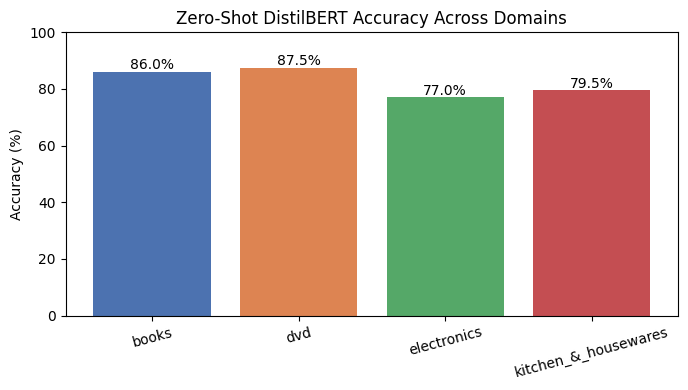

In [8]:
print('=' * 55)
print('  CROSS-DOMAIN ACCURACY SUMMARY')
print('=' * 55)
for d in DOMAINS:
    print(f'  {d:<25}: {domain_results[d]["acc"]*100:.2f}%')
overall_acc = np.mean([domain_results[d]['acc'] for d in DOMAINS])
print('-' * 55)
print(f'  {"Average across domains":<25}: {overall_acc*100:.2f}%')

for d in DOMAINS:
    print(f'\n--- {d} ---')
    print(classification_report(
        domain_results[d]['y_eval'], domain_results[d]['y_pred'],
        labels=[0, 1], target_names=['Negative', 'Positive'], zero_division=0
    ))

plt.figure(figsize=(7, 4))
accs = [domain_results[d]['acc'] * 100 for d in DOMAINS]
bars = plt.bar(DOMAINS, accs, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.ylabel('Accuracy (%)')
plt.title('Zero-Shot DistilBERT Accuracy Across Domains')
plt.ylim(0, 100)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 1, f'{acc:.1f}%', ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


=== Domain: books ===
Review    : review unique_id 0312355645 horrible_book _horrible mark_gospri unique_id asin 0
Prediction: Negative
Top contributing words (weight > 0 pushes toward Positive):
    got             -0.025  -> pushes toward Negative
    entire          -0.022  -> pushes toward Negative
    running         -0.021  -> pushes toward Negative
    lit             -0.021  -> pushes toward Negative
    have            +0.014  -> pushes toward Positive
    review          +0.012  -> pushes toward Positive
    relationship    +0.008  -> pushes toward Positive
    than            +0.004  -> pushes toward Positive


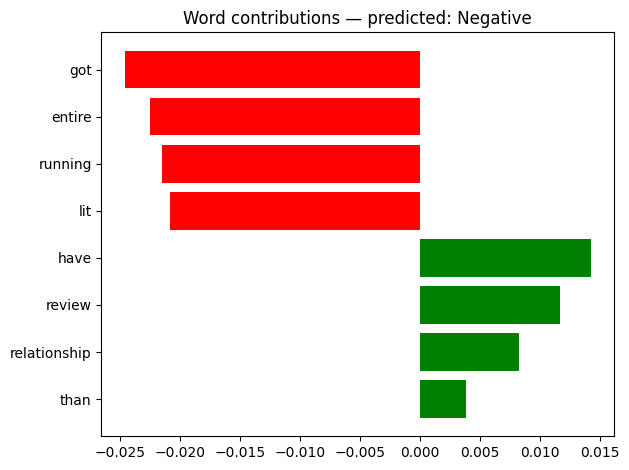


=== Domain: dvd ===
Review    : review unique_id b00064ljve one_of_the_worst_movies_i_have_ever_seen fer360 uniq
Prediction: Negative
Top contributing words (weight > 0 pushes toward Positive):
    29              -0.062  -> pushes toward Negative
    love            -0.039  -> pushes toward Negative
    this            -0.039  -> pushes toward Negative
    jesse           +0.029  -> pushes toward Positive
    even            -0.029  -> pushes toward Negative
    couldn          +0.025  -> pushes toward Positive
    fran            +0.017  -> pushes toward Positive
    widescreen      -0.000  -> pushes toward Negative


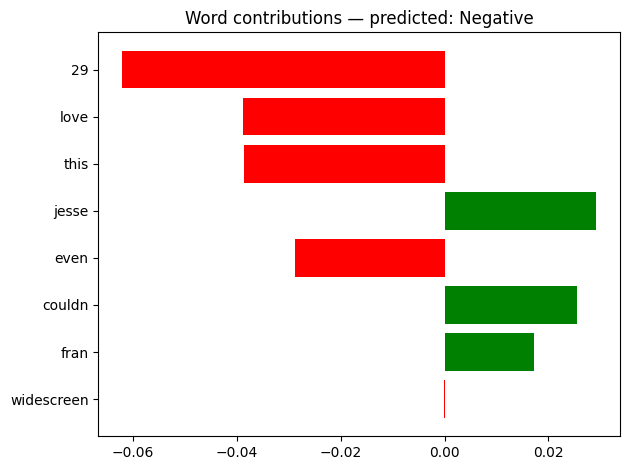


=== Domain: electronics ===
Review    : review unique_id b00005ukbg bad j _brodeur_ disgusted_consumer unique_id asin b0
Prediction: Negative
Top contributing words (weight > 0 pushes toward Positive):
    break           -0.006  -> pushes toward Negative
    fitting         -0.003  -> pushes toward Negative
    it              -0.002  -> pushes toward Negative
    consumer        -0.002  -> pushes toward Negative
    putting         +0.001  -> pushes toward Positive
    one             +0.001  -> pushes toward Positive
    storage         -0.001  -> pushes toward Negative
    atlantic        +0.000  -> pushes toward Positive


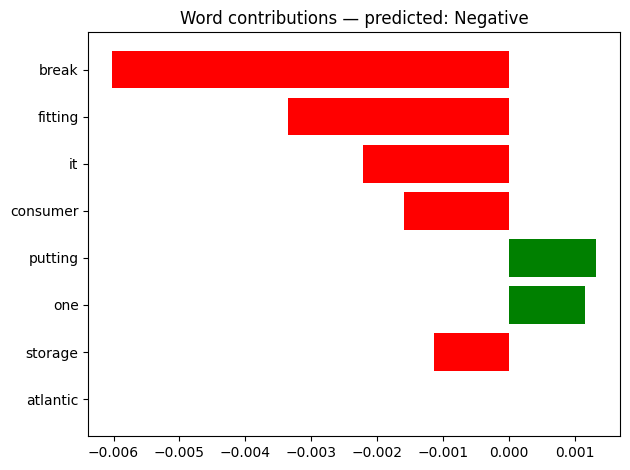


=== Domain: kitchen_&_housewares ===
Review    : review unique_id b0002d31qu doesn t_keep_my_yappy_cairn_from_barking d _overton 
Prediction: Negative
Top contributing words (weight > 0 pushes toward Positive):
    t               -0.073  -> pushes toward Negative
    not             -0.065  -> pushes toward Negative
    away            -0.058  -> pushes toward Negative
    working         +0.047  -> pushes toward Positive
    date            +0.036  -> pushes toward Positive
    terriers        -0.021  -> pushes toward Negative
    review          -0.012  -> pushes toward Negative
    sprays          -0.009  -> pushes toward Negative


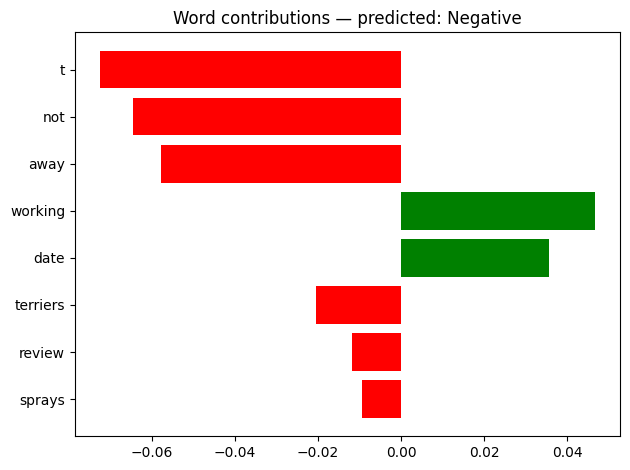

In [9]:
explainer = LimeTextExplainer(class_names=['Negative', 'Positive'])

def explain_review(text: str, num_features: int = 8, show_plot: bool = True):
    cleaned = clean_sentence(text)
    pred = model_predict(cleaned)
    label = 'Positive' if pred == 1 else 'Negative'

    exp = explainer.explain_instance(
        cleaned, model_predict_proba, num_features=num_features, num_samples=200
    )

    print(f'Review    : {text[:80]}')
    print(f'Prediction: {label}')
    print('Top contributing words (weight > 0 pushes toward Positive):')
    for word, weight in exp.as_list():
        direction = 'Positive' if weight > 0 else 'Negative'
        print(f'    {word:<15} {weight:+.3f}  -> pushes toward {direction}')

    if show_plot:
        fig = exp.as_pyplot_figure()
        plt.title(f'Word contributions — predicted: {label}')
        plt.tight_layout()
        plt.show()

    return exp

# One explained example per domain
for d in DOMAINS:
    x, y = domain_data[d]
    sample_idx = next(i for i, label in enumerate(y) if x[i].strip())
    print(f'\n=== Domain: {d} ===')
    explain_review(x[sample_idx])

--- Live Demo (Explainable, Cross-Domain) ---

Review : I really recommend this book
Result : ✅ Positive Review
Review    : I really recommend this book
Prediction: Positive
Top contributing words (weight > 0 pushes toward Positive):
    recommend       +0.003  -> pushes toward Positive
    really          +0.002  -> pushes toward Positive
    book            +0.002  -> pushes toward Positive
    i               +0.001  -> pushes toward Positive
    this            +0.001  -> pushes toward Positive


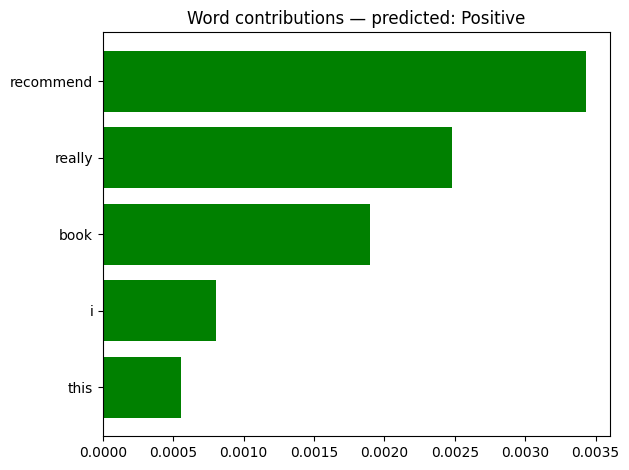


Review : The dvd included a big poster of my favorite hero. I cant wa
Result : ❌ Negative Review
Review    : The dvd included a big poster of my favorite hero. I cant wait for the second ep
Prediction: Negative
Top contributing words (weight > 0 pushes toward Positive):
    wait            -0.312  -> pushes toward Negative
    poster          -0.284  -> pushes toward Negative
    favorite        +0.230  -> pushes toward Positive
    episode         -0.202  -> pushes toward Negative
    second          -0.173  -> pushes toward Negative
    dvd             -0.138  -> pushes toward Negative


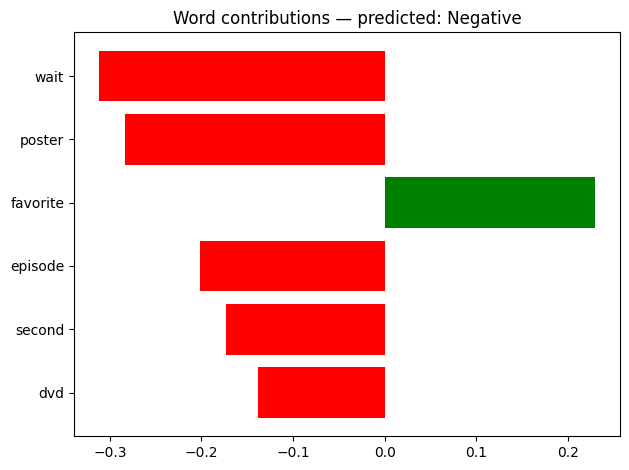


Review : I dont know what I just read, the book is full of nonsense
Result : ❌ Negative Review
Review    : I dont know what I just read, the book is full of nonsense
Prediction: Negative
Top contributing words (weight > 0 pushes toward Positive):
    nonsense        -0.198  -> pushes toward Negative
    dont            -0.171  -> pushes toward Negative
    what            -0.068  -> pushes toward Negative
    full            -0.046  -> pushes toward Negative
    know            -0.037  -> pushes toward Negative
    the             -0.030  -> pushes toward Negative


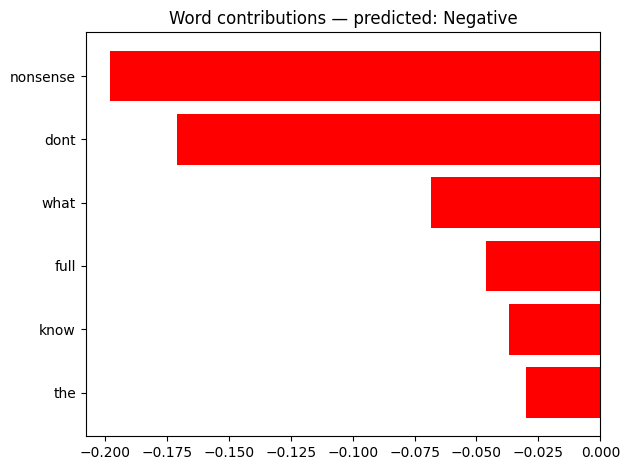


Review : The book is very huge with too many unnecessary details. Jus
Result : ❌ Negative Review
Review    : The book is very huge with too many unnecessary details. Just buy another book!
Prediction: Negative
Top contributing words (weight > 0 pushes toward Positive):
    too             -0.269  -> pushes toward Negative
    unnecessary     -0.247  -> pushes toward Negative
    just            -0.072  -> pushes toward Negative
    book            +0.065  -> pushes toward Positive
    huge            +0.064  -> pushes toward Positive
    another         -0.039  -> pushes toward Negative


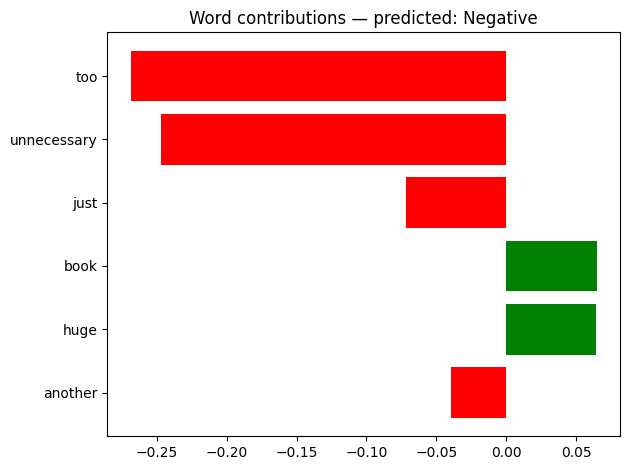

In [10]:
def predict_and_explain(review: str):
    cleaned = clean_sentence(review)
    result = model_predict(cleaned)
    label = '✅ Positive Review' if result == 1 else '❌ Negative Review'
    print(f'Review : {review[:60]}')
    print(f'Result : {label}')
    explain_review(review, num_features=6)
    print()

print('--- Live Demo (Explainable, Cross-Domain) ---\n')
predict_and_explain('I really recommend this book')
predict_and_explain('The dvd included a big poster of my favorite hero. I cant wait for the second episode')
predict_and_explain('I dont know what I just read, the book is full of nonsense')
predict_and_explain('The book is very huge with too many unnecessary details. Just buy another book!')